In [99]:
import numpy as np
import bayesflow as bf
import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns
import bayesflow.diagnostics as diag

In [ ]:
import numpy as np

def theta_step(batch_shape=1, mu=0.0, sigma=1.0):
    # 1. Generate mu (scalar), mu ~ Normal(loc=mu, scale=sigma)
    mu_val = np.random.normal(loc=mu, scale=sigma)
    mu_sample = np.float32(mu_val)
    
    # 2. Return parameter dictionary for consistency
    theta = np.array([mu_sample], dtype=np.float32)
    return {"theta": theta}


def forward_step(theta, **kwargs):
    # 1. Extract mu
    mu = theta[0]  # Note: using index 0
    
    # 2. Generate observation data
    obs = np.random.normal(loc=mu, scale=1.0, size=(100, 1)).astype(np.float32)
    
    return {"x": obs}


In [101]:
simulator = bf.make_simulator(
    [theta_step, forward_step],
    expand_outputs=False
)


def flatten_inference_conditions(data, **kwargs):
    if "inference_conditions" in data:
        conditions = data["inference_conditions"]
        data["inference_conditions"] = conditions.reshape(conditions.shape[0], -1)
    return data

adapter = (
    bf.adapters.Adapter()
    .to_array()
    .convert_dtype("float64", "float32")  
    .rename("theta", "inference_variables")
    .rename("x", "inference_conditions")
    .append(flatten_inference_conditions)
)

In [102]:
num_training_batches   = 500
num_batch_size            = 32
num_epochs                = 15

In [ ]:
test_size = 1
test_batch = simulator.sample((test_size,))

# Extract theta_true and x_test
theta_true = test_batch["theta"]  # [test_size, 48]
x_test = test_batch["x"]  # [test_size, 4700]

# Set the number of posterior samples
num_samples = 300


In [ ]:
# Define the inference network
affine_flow = bf.networks.CouplingFlow(subnet="mlp")

affine_flow_workflow = bf.BasicWorkflow(
    simulator=simulator,
    adapter=adapter,
    inference_network=affine_flow,
)



In [ ]:
# Fit the model
history = affine_flow_workflow.fit_online(
    epochs=num_epochs,
    number_batches=num_training_batches,
    batch_size=num_batch_size,
)

INFO:bayesflow:Fitting on dataset instance of OnlineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: -0.1084 - loss/inference_loss: -0.1084
Epoch 2/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: -0.3858 - loss/inference_loss: -0.3858
Epoch 3/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: -0.4373 - loss/inference_loss: -0.4373
Epoch 4/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: -0.4499 - loss/inference_loss: -0.4499
Epoch 5/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: -0.5358 - loss/inference_loss: -0.5358
Epoch 6/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: -0.6356 - loss/inference_loss: -0.6356
Epoch 7/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: -0.6602 - loss/inference_loss: -0.6602
Epoch 8/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: -0.6762 - loss/inference_loss: -0.6762
Epoch 9/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: -0.6881 - loss/inference_loss: -0.6881
Epoch 10/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: -0.7428 - loss/inference_loss: -0.7428

In [ ]:
test_size = 1 
test_batch = simulator.sample((test_size,))

# Extract theta_true and x_test
theta_true = test_batch["theta"]  # [test_size, 48]
x_test = test_batch["x"]  # [test_size, 4700]

# Set the number of posterior samples
num_samples = 300

posterior_samples_affine = affine_flow_workflow.approximator.sample(
    conditions={"inference_conditions": x_test}, 
    num_samples=num_samples
)["theta"]


In [122]:
def bayes_estimator(Z, mu_0=1.0, m=1.0, sigma_0=1.0, n_samples=300):
    """
    Implements a Bayesian estimator that calculates the posterior distribution 
    based on the prior and observed data, and samples from it using numpy.

    Parameters:
    - Z: Input data, expected shape (1, n_obs, 1).
    - mu_0: Prior mean.
    - m: Prior pseudo-sample size.
    - sigma_0: Prior standard deviation.
    - n_samples: Number of posterior samples to draw.

    Returns:
    - posterior_samples: Samples drawn from the posterior distribution, shape (n_samples,).
    """
    # Ensure Z is a numpy array
    Z = np.array(Z, dtype=np.float32)

    # Compute the mean over the observation dimension (axis=1)
    y_bar = np.mean(Z, axis=1)  # Shape: (batch_size, 1)
    n = Z.shape[1]  # Number of observations (n_obs)

    # Compute posterior mean and standard deviation
    posterior_mean = (m * mu_0 + n * y_bar) / (m + n)  # Shape: (batch_size, 1)
    posterior_stddev = sigma_0 / np.sqrt(m + n)  # Scalar

    # Sample from the posterior distribution using numpy
    posterior_samples = np.random.normal(loc=posterior_mean, scale=posterior_stddev, size=(n_samples, *posterior_mean.shape))

    return posterior_samples.squeeze()


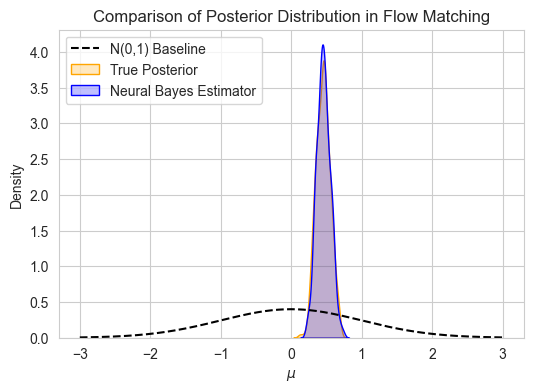

In [ ]:


# Extract tau samples (for the first test sample)
mu_samples = posterior_samples_affine[0, :, -1]  # shape: (300,)
mu_true = theta_true[0, -1]  # Scalar

plt.figure(figsize=(6, 4))

# Generate density curve for N(0,1)
x = np.linspace(-3, 3, 1000)  # Set x-axis range
y = stats.norm.pdf(x, loc=0, scale=1)  # Compute probability density of N(0,1)

# Plot N(0,1) curve on the same graph
plt.plot(x, y, label="N(0,1) Baseline", color="black", linestyle="--")

# Compute reference posterior
reference_posterior = bayes_estimator(x_test)

# Plot KDE for the posterior distributions
sns.kdeplot(reference_posterior, label="True Posterior", fill=True, color="orange")
sns.kdeplot(mu_samples, fill=True, color="blue", label="Neural Bayes Estimator")

# Labels and legend
plt.title("Comparison of Posterior Distribution in Flow Matching")
plt.xlabel("$\mu$")
plt.ylabel("Density")
plt.legend()
plt.show()


In [117]:
test_size = 100
test_batch_100 = simulator.sample((test_size,))

theta_true_100 = test_batch_100["theta"]  # [test_size, 48]
x_test_100 = test_batch_100["x"]  # [test_size, 4700]

In [ ]:
posterior_samples_affine= affine_flow_workflow.approximator.sample(
    conditions={"inference_conditions": x_test_100},  # Use the test data
    num_samples=300
)["theta"]

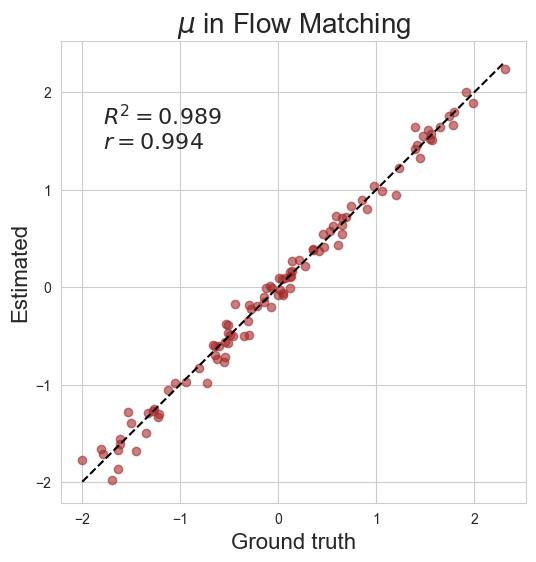

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# Compute posterior means => shape (test_size, 48)
posterior_means = posterior_samples_affine.mean(axis=1)

# Select the first dimension for plotting
i = 0

plt.figure(figsize=(6, 6))
plt.scatter(theta_true_100[:, i], posterior_means[:, i], alpha=0.6, color="brown")

# Plot diagonal line
min_val = min(theta_true_100[:, i].min(), posterior_means[:, i].min())
max_val = max(theta_true_100[:, i].max(), posterior_means[:, i].max())
plt.plot([min_val, max_val], [min_val, max_val], "k--")

# Compute correlation coefficient & R²
r = np.corrcoef(theta_true_100[:, i], posterior_means[:, i])[0, 1]
r2 = r2_score(theta_true_100[:, i], posterior_means[:, i])

# Annotate R² and r in the top-left corner
plt.text(min_val + 0.05 * (max_val - min_val), 
         max_val - 0.1 * (max_val - min_val), 
         f'$R^2 = {r2:.3f}$\n$r = {r:.3f}$', 
         fontsize=16, 
         ha='left', 
         va='top')

plt.title(r"$\mu$ in Flow Matching", fontsize=20)
plt.xlabel("Ground truth", fontsize=16)
plt.ylabel("Estimated", fontsize=16)

plt.show()


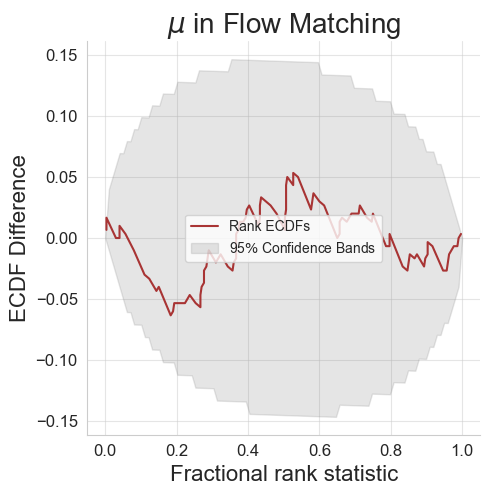

In [ ]:
import matplotlib.pyplot as plt

f = diag.calibration_ecdf(
    targets=posterior_samples_affine,
    references=theta_true_100,
    stacked=True,
    difference=True,
    legend_fontsize=12,
    figsize=(5, 5)
)

# Modify line colors in the plot
for i, line in enumerate(f.axes[0].get_lines()):
    if i == 0:  # First label (Rank ECDF)
        line.set_color("brown")
    else:
        line.set_color("gray")  # Keep confidence interval in gray

# Modify legend color
legend = f.axes[0].legend()
legend.get_lines()[0].set_color("brown")  # Set first legend line to brown

# Change title to \mu
f.axes[0].set_title(r"$\mu$ in Flow Matching", fontsize=20)  # Use LaTeX syntax

plt.show()
